# Portfolio robustness and long--short fragility strategies

This notebook tests whether the primary long-only result is sensitive to portfolio breadth and weighting, then evaluates exploratory zero-investment strategies that are long low-fragility stocks and short high-fragility stocks. It uses the Fragility Scores constructed in Notebook 10.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

project_root = Path.cwd().resolve()
while not (project_root / 'src').is_dir():
    if project_root == project_root.parent:
        raise RuntimeError('Project root could not be located.')
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.evaluation.robustness import build_investment_robustness
from src.utils.configuration import get_paths_config
from src.visualization.style import (
    COLOR_PALETTE, SINGLE_PANEL_SIZE, apply_matplotlib_layout,
    set_matplotlib_style,
)

paths = get_paths_config()
evaluation_tables = paths.tables / 'evaluation'
robustness_tables = paths.tables / 'robustness'
set_matplotlib_style()

## Build the robustness portfolios

The long-only checks vary the exclusion threshold and weighting rule. DFRAG-10 is long Decile 1 and short Decile 10; DFRAG-20 is long Deciles 1--2 and short Deciles 9--10. Each leg is equally weighted at formation and held until the next quarterly rebalance.

In [2]:
build_investment_robustness(
    signals_path=evaluation_tables / 'fragility_stock_quarters.parquet',
    sample_path=paths.processed / 'modeling' / 'modeling_sample.parquet',
    daily_stock_path=paths.raw / 'crsp' / 'daily_stock.parquet',
    primary_daily_path=(
        evaluation_tables / 'fragility_strategy_daily_returns.parquet'
    ),
    output_directory=robustness_tables,
    overwrite=True,
)

InvestmentRobustnessResult(created=True, daily_returns_path=WindowsPath('C:/Users/salio/OneDrive/Desktop/Master Thesis/results/tables/robustness/investment_robustness_daily_returns.parquet'), performance_path=WindowsPath('C:/Users/salio/OneDrive/Desktop/Master Thesis/results/tables/robustness/investment_robustness_performance.csv'), turnover_path=WindowsPath('C:/Users/salio/OneDrive/Desktop/Master Thesis/results/tables/robustness/investment_robustness_turnover.csv'), costs_path=WindowsPath('C:/Users/salio/OneDrive/Desktop/Master Thesis/results/tables/robustness/investment_robustness_costs.csv'), alpha_path=WindowsPath('C:/Users/salio/OneDrive/Desktop/Master Thesis/results/tables/robustness/investment_robustness_alpha_hac.csv'), factor_performance_path=WindowsPath('C:/Users/salio/OneDrive/Desktop/Master Thesis/results/tables/robustness/fragility_factor_risk_management_performance.csv'), factor_alpha_path=WindowsPath('C:/Users/salio/OneDrive/Desktop/Master Thesis/results/tables/robustnes

## Long-only screening and weighting sensitivity

In [3]:
strategy_labels = {
    'equal_all': 'Equal-weighted universe',
    'equal_exclude_d10': 'Equal weighted: exclude Decile 10',
    'equal_exclude_top20': 'Equal weighted: exclude top 20%',
    'value_all': 'Value-weighted universe',
    'value_exclude_d10': 'Value weighted: exclude Decile 10',
}
performance = pd.read_csv(
    robustness_tables / 'investment_robustness_performance.csv'
)
performance['label'] = performance['strategy'].map(strategy_labels)
display(performance[[
    'label', 'annualized_return', 'annualized_volatility',
    'sharpe_ratio', 'maximum_drawdown', 'downside_volatility',
]].style.format({
    'annualized_return': '{:.2%}', 'annualized_volatility': '{:.2%}',
    'sharpe_ratio': '{:.3f}', 'maximum_drawdown': '{:.2%}',
    'downside_volatility': '{:.2%}',
}))
performance.drop(columns='label').to_latex(
    paths.tables / '04_12_portfolio_robustness_performance.tex',
    index=False, float_format='%.4f',
    caption='Long-only portfolio robustness results.',
    label='tab:portfolio-robustness-performance',
)

,label,annualized_return,annualized_volatility,sharpe_ratio,maximum_drawdown,downside_volatility
0,Equal-weighted universe,7.82%,20.37%,0.239,26.50%,14.14%
1,Equal weighted: exclude Decile 10,13.84%,19.52%,0.519,24.11%,13.29%
2,Equal weighted: exclude top 20%,13.36%,18.49%,0.515,23.40%,12.50%
3,Value-weighted universe,19.32%,16.64%,0.861,19.39%,11.30%
4,Value weighted: exclude Decile 10,19.23%,16.62%,0.857,19.37%,11.29%


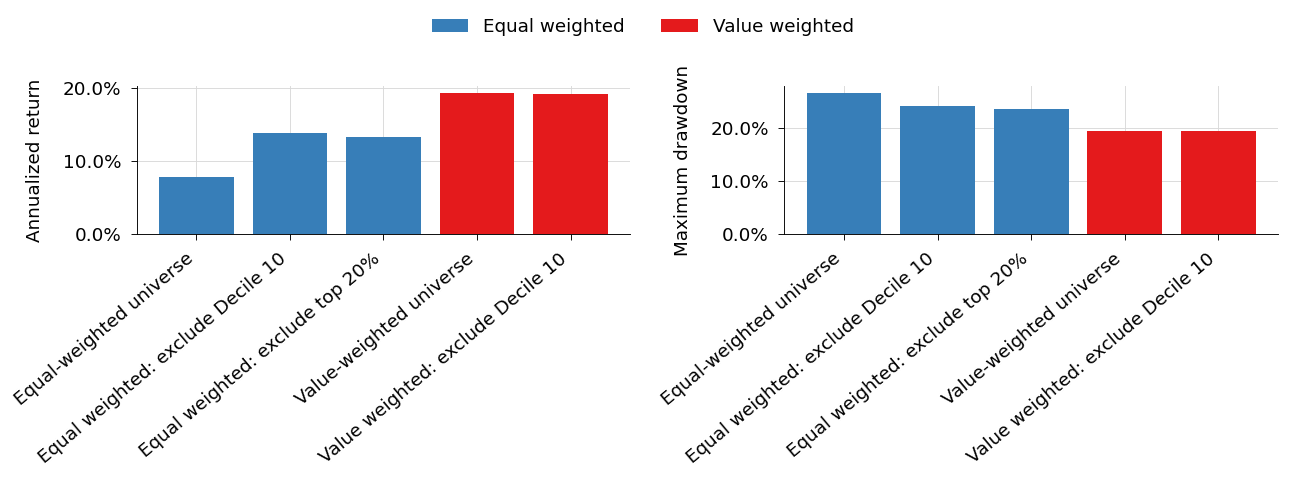

In [4]:
portfolio_measures = [
    ('annualized_return', 'Annualized return'),
    ('maximum_drawdown', 'Maximum drawdown'),
]
positions = np.arange(len(performance))
bar_colors = [
    COLOR_PALETTE[0] if strategy.startswith('equal_') else COLOR_PALETTE[1]
    for strategy in performance['strategy']
]
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
for index, (axis, (column, label)) in enumerate(
    zip(axes, portfolio_measures)
):
    axis.bar(positions, performance[column], color=bar_colors)
    axis.set_ylabel(label)
    axis.set_xticks(positions)
    axis.set_xticklabels(performance['label'], rotation=40, ha='right')
    axis.yaxis.set_major_formatter(PercentFormatter(1.0))
legend_handles = [
    Patch(facecolor=COLOR_PALETTE[0], label='Equal weighted'),
    Patch(facecolor=COLOR_PALETTE[1], label='Value weighted'),
]
apply_matplotlib_layout(figure)
figure.subplots_adjust(top=0.82)
figure.legend(
    handles=legend_handles, loc='upper center', ncol=2,
    bbox_to_anchor=(0.5, 0.99), frameon=False,
)
figure.savefig(paths.figures / '04_12_portfolio_robustness.pdf')
plt.show()

## Exploratory long--short strategies

In [5]:
factor_labels = {
    'original': 'DFRAG-10',
    'dfrag_20': 'DFRAG-20',
    'half_exposure': 'DFRAG-10: half exposure',
    'volatility_managed': 'DFRAG-10: volatility managed',
}
factor_performance = pd.read_csv(
    robustness_tables / 'fragility_factor_risk_management_performance.csv'
)
factor_performance['label'] = factor_performance['strategy'].map(factor_labels)
long_short = factor_performance.loc[
    factor_performance['strategy'].isin(
        ['original', 'dfrag_20', 'volatility_managed']
    )
].copy()
display(long_short[[
    'label', 'annualized_return', 'annualized_volatility',
    'sharpe_ratio', 'maximum_drawdown', 'downside_volatility',
]].style.format({
    'annualized_return': '{:.2%}', 'annualized_volatility': '{:.2%}',
    'sharpe_ratio': '{:.3f}', 'maximum_drawdown': '{:.2%}',
    'downside_volatility': '{:.2%}',
}))
long_short.drop(columns='label').to_latex(
    paths.tables / '04_13_long_short_fragility_performance.tex',
    index=False, float_format='%.4f',
    caption='Exploratory long--short Fragility Score strategies.',
    label='tab:long-short-fragility-performance',
)

,label,annualized_return,annualized_volatility,sharpe_ratio,maximum_drawdown,downside_volatility
0,DFRAG-10,55.70%,34.61%,1.452,41.37%,21.88%
1,DFRAG-20,15.97%,29.60%,0.648,42.46%,18.91%
3,DFRAG-10: volatility managed,28.21%,17.29%,1.524,21.10%,10.79%


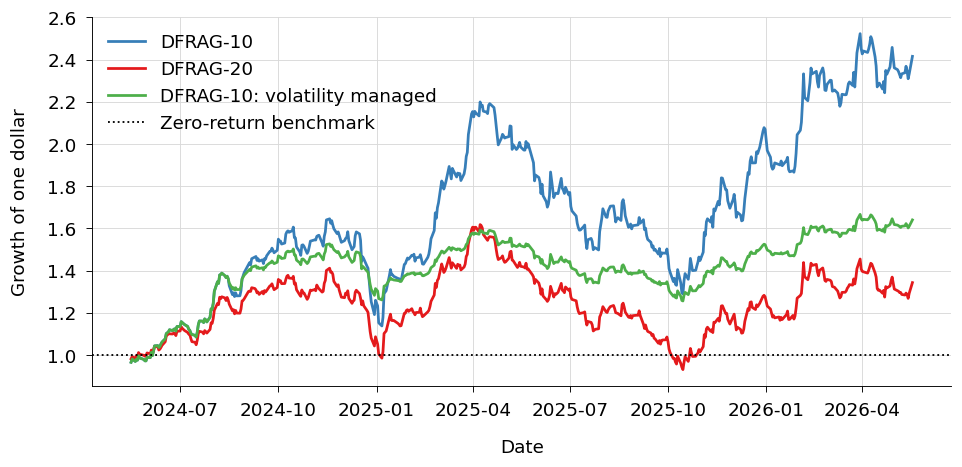

In [6]:
daily = pd.read_parquet(
    robustness_tables / 'investment_robustness_daily_returns.parquet'
)
factor_columns = {
    'defensive_fragility_factor_return': 'DFRAG-10',
    'defensive_fragility_factor_20_return': 'DFRAG-20',
    'volatility_managed_fragility_factor_return': 'DFRAG-10: volatility managed',
}
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
for index, (column, label) in enumerate(factor_columns.items()):
    wealth = (1 + daily[column]).cumprod()
    axis.plot(daily['date'], wealth, color=COLOR_PALETTE[index], label=label)
axis.axhline(
    1, color='black', linewidth=1.2, linestyle=':',
    label='Zero-return benchmark',
)
axis.set_xlabel('Date')
axis.set_ylabel('Growth of one dollar')
axis.legend(frameon=False)
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_12_long_short_fragility_wealth.pdf')
plt.show()

## Turnover and transaction costs

In [7]:
turnover = pd.read_csv(
    robustness_tables / 'investment_robustness_turnover.csv'
)
turnover_summary = (
    turnover.loc[turnover['strategy'].isin(
        ['dfrag_10', 'dfrag_20', 'volatility_managed']
    )]
    .groupby('strategy', as_index=False)
    .agg(mean_one_way_turnover=('one_way_turnover', 'mean'))
)
turnover_summary['strategy'] = turnover_summary['strategy'].replace({
    'dfrag_10': 'DFRAG-10',
    'dfrag_20': 'DFRAG-20',
    'volatility_managed': 'DFRAG-10: volatility managed',
})
display(turnover_summary.style.format({'mean_one_way_turnover': '{:.2%}'}))

costs = pd.read_csv(robustness_tables / 'investment_robustness_costs.csv')
long_short_costs = costs.loc[
    costs['strategy'].isin(
        ['dfrag_10', 'dfrag_20', 'volatility_managed']
    )
].copy()
long_short_costs['label'] = long_short_costs['strategy'].replace({
    'dfrag_10': 'DFRAG-10',
    'dfrag_20': 'DFRAG-20',
    'volatility_managed': 'DFRAG-10: volatility managed',
})
display(long_short_costs[[
    'cost_bps', 'label', 'annualized_return', 'sharpe_ratio',
    'maximum_drawdown',
]].style.format({
    'annualized_return': '{:.2%}', 'sharpe_ratio': '{:.3f}',
    'maximum_drawdown': '{:.2%}',
}))

,strategy,mean_one_way_turnover
0,DFRAG-10,96.16%
1,DFRAG-20,83.30%
2,DFRAG-10: volatility managed,130.71%


,cost_bps,label,annualized_return,sharpe_ratio,maximum_drawdown
2,10,DFRAG-10,55.10%,1.441,41.47%
3,10,DFRAG-20,15.58%,0.636,42.54%
4,10,DFRAG-10: volatility managed,27.53%,1.491,21.28%
7,25,DFRAG-10,54.20%,1.424,41.61%
8,25,DFRAG-20,15.00%,0.619,42.66%
9,25,DFRAG-10: volatility managed,26.52%,1.442,21.55%
12,50,DFRAG-10,52.70%,1.395,41.86%
13,50,DFRAG-20,14.04%,0.590,42.86%
14,50,DFRAG-10: volatility managed,24.86%,1.360,21.99%


## Factor-adjusted performance and risk-management variants

,label,annualized_alpha,alpha_t_statistic,alpha_p_value,adjusted_r_squared
0,DFRAG-10,53.58%,2.250,0.024,0.403
1,DFRAG-20,22.26%,1.217,0.224,0.519
3,DFRAG-10: volatility managed,27.08%,1.898,0.058,0.366


,label,annualized_return,annualized_volatility,sharpe_ratio,maximum_drawdown
0,DFRAG-10,55.70%,34.61%,1.452,41.37%
1,DFRAG-20,15.97%,29.60%,0.648,42.46%
3,DFRAG-10: volatility managed,28.21%,17.29%,1.524,21.10%


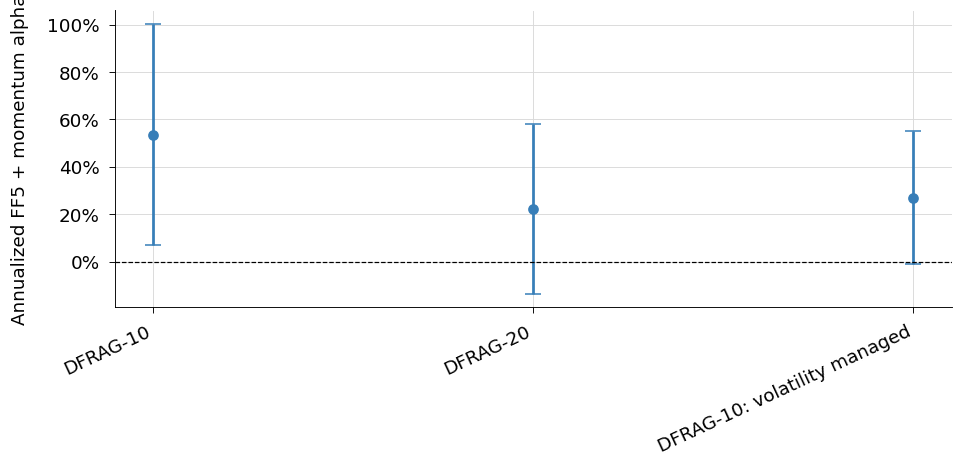

In [8]:
factor_alpha = pd.read_csv(
    robustness_tables / 'fragility_factor_risk_management_alpha.csv'
)
factor_alpha['label'] = factor_alpha['strategy'].map(factor_labels)
reported_strategies = ['original', 'dfrag_20', 'volatility_managed']
reported_factor_alpha = factor_alpha.loc[
    factor_alpha['strategy'].isin(reported_strategies)
].copy()
reported_factor_performance = factor_performance.loc[
    factor_performance['strategy'].isin(reported_strategies)
].copy()
display(reported_factor_alpha[[
    'label', 'annualized_alpha', 'alpha_t_statistic',
    'alpha_p_value', 'adjusted_r_squared',
]].style.format({
    'annualized_alpha': '{:.2%}', 'alpha_t_statistic': '{:.3f}',
    'alpha_p_value': '{:.3f}', 'adjusted_r_squared': '{:.3f}',
}))
display(reported_factor_performance[[
    'label', 'annualized_return', 'annualized_volatility',
    'sharpe_ratio', 'maximum_drawdown',
]].style.format({
    'annualized_return': '{:.2%}', 'annualized_volatility': '{:.2%}',
    'sharpe_ratio': '{:.3f}', 'maximum_drawdown': '{:.2%}',
}))
reported_factor_alpha.drop(columns='label').to_latex(
    paths.tables / '04_14_long_short_fragility_alpha.tex',
    index=False, float_format='%.4f',
    caption='FF5-plus-momentum alpha for fragility-factor specifications.',
    label='tab:long-short-fragility-alpha',
)

reported_factor_alpha['ci95'] = (
    1.96 * 252 * reported_factor_alpha['alpha_standard_error']
)
positions = np.arange(len(reported_factor_alpha))
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.errorbar(
    positions, reported_factor_alpha['annualized_alpha'],
    yerr=reported_factor_alpha['ci95'], fmt='o', capsize=5,
    color=COLOR_PALETTE[0], ecolor=COLOR_PALETTE[0],
)
axis.axhline(0, color='black', linewidth=0.8, linestyle='--')
axis.set_ylabel('Annualized FF5 + momentum alpha')
axis.set_xticks(positions)
axis.set_xticklabels(
    reported_factor_alpha['label'], rotation=25, ha='right'
)
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_12_long_short_fragility_alpha.pdf')
plt.show()